# Classification

In [14]:
import numpy as np
import os

from pathlib import Path
from logistic_regression import (
    evaluate_linear_split,
    evaluate_split,
    add_bias,
    train_linear_model,
    train_threshold_models,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [15]:
X_train=np.load("X_train.npy")
X_val=np.load("X_val.npy")
X_test=np.load("X_test.npy")

In [16]:
y_train_classified=np.load("y_train_classified.npy").ravel()
y_val_classified=np.load("y_val_classified.npy").ravel()
y_test_classified=np.load("y_test_classified.npy").ravel()

y_train_scaled=np.load("y_train_scaled.npy").ravel()
y_val_scaled=np.load("y_val_scaled.npy").ravel()
y_test_scaled=np.load("y_test_scaled.npy").ravel()

## KNN

In [17]:
for i in [9,11,13,15,17]:
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train_classified)
    y_val_pred_classification=knn.predict(X_val)
    print('_'*10)
    print(i)
    print(classification_report(y_val_classified,y_val_pred_classification))

__________
9
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     38124
           1       0.60      0.60      0.60     34004
           2       0.79      0.68      0.73     27872

    accuracy                           0.72    100000
   macro avg       0.72      0.71      0.72    100000
weighted avg       0.72      0.72      0.72    100000

__________
11
              precision    recall  f1-score   support

           0       0.79      0.87      0.83     38124
           1       0.62      0.62      0.62     34004
           2       0.81      0.69      0.75     27872

    accuracy                           0.74    100000
   macro avg       0.74      0.73      0.73    100000
weighted avg       0.74      0.74      0.74    100000

__________
13
              precision    recall  f1-score   support

           0       0.81      0.88      0.84     38124
           1       0.63      0.63      0.63     34004
           2       0.81      0.70 

In [18]:
knn_model=KNeighborsClassifier(n_neighbors=17)
knn_model.fit(X_train,y_train_classified)
print("Training")
y_pred_train_classification=knn_model.predict(X_train)
print(classification_report(y_train_classified,y_pred_train_classification))
print("Validation")
y_val_pred_classification=knn_model.predict(X_val)
print(classification_report(y_val_classified,y_val_pred_classification))

Training
              precision    recall  f1-score   support

           0       0.86      0.92      0.89    305245
           1       0.72      0.74      0.73    271332
           2       0.87      0.77      0.82    223423

    accuracy                           0.81    800000
   macro avg       0.82      0.81      0.81    800000
weighted avg       0.82      0.81      0.81    800000

Validation
              precision    recall  f1-score   support

           0       0.82      0.89      0.85     38124
           1       0.65      0.66      0.65     34004
           2       0.83      0.72      0.77     27872

    accuracy                           0.76    100000
   macro avg       0.77      0.76      0.76    100000
weighted avg       0.76      0.76      0.76    100000



## Linear Regression (MapReduce)

In [19]:
java17_home = Path("/usr/lib/jvm/java-17-openjdk-amd64")
if java17_home.exists():
    os.environ["JAVA_HOME"] = str(java17_home)
    os.environ["PATH"] = f"{java17_home / 'bin'}:{os.environ.get('PATH', '')}"

try:
    from pyspark import StorageLevel
    from pyspark.sql import SparkSession
except ImportError as exc:
    raise ImportError(
        "Install pyspark first. If you use the project venv, run: .venv/bin/pip install pyspark"
    ) from exc

sample_size = None
rng = np.random.default_rng(42)

if sample_size is None:
    X_train_used = X_train
    y_train_used = y_train_scaled
else:
    sample_size = min(sample_size, len(X_train))
    sample_idx = rng.choice(len(X_train), size=sample_size, replace=False)
    X_train_used = X_train[sample_idx]
    y_train_used = y_train_scaled[sample_idx]

X_train_used = add_bias(X_train_used)
X_val_bias = add_bias(X_val)
X_test_bias = add_bias(X_test)

print("Train sample:", X_train_used.shape, y_train_used.shape)
print("Validation:", X_val_bias.shape, y_val_scaled.shape)
print("Test:", X_test_bias.shape, y_test_scaled.shape)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("spark-map-reduce-linear-regression-mse")
    .config("spark.driver.memory", os.environ.get("SPARK_DRIVER_MEMORY", "6g"))
    .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "6g"))
    .getOrCreate()
)
sc = spark.sparkContext
sc.setLogLevel("ERROR")

num_partitions = max(2, min(8, sc.defaultParallelism))
partition_edges = np.linspace(0, len(y_train_used), num_partitions + 1, dtype=int)
train_batches = [
    (
        np.ascontiguousarray(X_train_used[partition_edges[i]:partition_edges[i + 1]], dtype=np.float32),
        np.ascontiguousarray(y_train_used[partition_edges[i]:partition_edges[i + 1]], dtype=np.float32),
    )
    for i in range(num_partitions)
    if partition_edges[i] < partition_edges[i + 1]
]

train_rdd = sc.parallelize(train_batches, numSlices=len(train_batches)).persist(StorageLevel.MEMORY_AND_DISK)
num_rows = train_rdd.map(lambda batch: int(batch[1].shape[0])).sum()

print("RDD partitions:", train_rdd.getNumPartitions())
print("Rows inside RDD:", num_rows)

print("\nTraining linear regression (map-reduce)")
linear_weights = train_linear_model(
    sc=sc,
    train_rdd=train_rdd,
    num_features=X_train_used.shape[1],
    epochs=25,
    lr=0.1,
    reg=0.0001,
)

print("Weights shape:", linear_weights.shape)
evaluate_linear_split("Validation", X_val_bias, y_val_scaled, linear_weights)
evaluate_linear_split("Test", X_test_bias, y_test_scaled, linear_weights)

spark.stop()

Train sample: (800000, 58) (800000,)
Validation: (100000, 58) (100000,)
Test: (100000, 58) (100000,)


RDD partitions: 8
Rows inside RDD: 800000

Training linear regression (map-reduce)


  epoch 01 | mse = 1.0000
  epoch 02 | mse = 0.8243
  epoch 05 | mse = 0.4735
  epoch 10 | mse = 0.2143
  epoch 15 | mse = 0.1239
  epoch 20 | mse = 0.0924


  epoch 25 | mse = 0.0814
Weights shape: (58,)

Validation MSE: 0.080565
Sample predictions (pred, true):
  (0.0007, 0.3065)
  (1.3874, 1.4466)
  (0.8331, 1.0927)
  (0.2786, 0.5030)
  (0.5569, 0.2278)

Test MSE: 0.080430
Sample predictions (pred, true):
  (-0.2753, 0.0706)
  (-0.2757, 0.2672)
  (0.8332, 1.3286)
  (-1.3887, -1.5806)
  (0.0011, 0.0706)


## Logistic Regression

In [20]:
java17_home = Path("/usr/lib/jvm/java-17-openjdk-amd64")
if java17_home.exists():
    os.environ["JAVA_HOME"] = str(java17_home)
    os.environ["PATH"] = f"{java17_home / 'bin'}:{os.environ.get('PATH', '')}"

try:
    from pyspark import StorageLevel
    from pyspark.sql import SparkSession
except ImportError as exc:
    raise ImportError(
        "Install pyspark first. If you use the project venv, run: .venv/bin/pip install pyspark"
    ) from exc

In [21]:
sample_size = None
rng = np.random.default_rng(42)

if sample_size is None:
    X_train_used = X_train
    y_train_used = y_train_classified
else:
    sample_size = min(sample_size, len(X_train))
    sample_idx = rng.choice(len(X_train), size=sample_size, replace=False)
    X_train_used = X_train[sample_idx]
    y_train_used = y_train_classified[sample_idx]

X_train_used = add_bias(X_train_used)
X_val_bias = add_bias(X_val)
X_test_bias = add_bias(X_test)

classes, counts = np.unique(y_train_used, return_counts=True)
print("Train sample:", X_train_used.shape, y_train_used.shape)
print("Validation:", X_val_bias.shape, y_val_classified.shape)
print("Test:", X_test_bias.shape, y_test_classified.shape)
print("Classes:", classes)
print("Train class counts:", dict(zip(classes.tolist(), counts.tolist())))

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("spark-map-reduce-ordinal-logistic-regression")
    .config("spark.driver.memory", os.environ.get("SPARK_DRIVER_MEMORY", "6g"))
    .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "6g"))
    .getOrCreate()
)
sc = spark.sparkContext
sc.setLogLevel("ERROR")

num_partitions = max(2, min(8, sc.defaultParallelism))
partition_edges = np.linspace(0, len(y_train_used), num_partitions + 1, dtype=int)
train_batches = [
    (
        np.ascontiguousarray(X_train_used[partition_edges[i]:partition_edges[i + 1]], dtype=np.float32),
        np.ascontiguousarray(y_train_used[partition_edges[i]:partition_edges[i + 1]], dtype=np.int64),
    )
    for i in range(num_partitions)
    if partition_edges[i] < partition_edges[i + 1]
]

train_rdd = sc.parallelize(train_batches, numSlices=len(train_batches)).persist(StorageLevel.MEMORY_AND_DISK)
num_rows = train_rdd.map(lambda batch: int(batch[1].shape[0])).sum()

print("RDD partitions:", train_rdd.getNumPartitions())
print("Rows inside RDD:", num_rows)

threshold_weights = train_threshold_models(
    sc=sc,
    train_rdd=train_rdd,
    num_features=X_train_used.shape[1],
    thresholds=(1, 2),
    epochs=25,
    lr=0.8,
    reg=0.0001,
)

print("Weights shape:", threshold_weights.shape)
evaluate_split("Validation", X_val_bias, y_val_classified, threshold_weights)
evaluate_split("Test", X_test_bias, y_test_classified, threshold_weights)

spark.stop()

Train sample: (800000, 58) (800000,)
Validation: (100000, 58) (100000,)
Test: (100000, 58) (100000,)
Classes: [0 1 2]
Train class counts: {0: 305245, 1: 271332, 2: 223423}


RDD partitions: 8
Rows inside RDD: 800000

Training threshold y >= 1


  epoch 01 | loss = 0.6931
  epoch 02 | loss = 0.5695


  epoch 05 | loss = 0.3853


  epoch 10 | loss = 0.2902


  epoch 15 | loss = 0.2511
  epoch 20 | loss = 0.2294
  epoch 25 | loss = 0.2153

Training threshold y >= 2
  epoch 01 | loss = 0.6931
  epoch 02 | loss = 0.5544
  epoch 05 | loss = 0.3746
  epoch 10 | loss = 0.2910


  epoch 15 | loss = 0.2544
  epoch 20 | loss = 0.2334
  epoch 25 | loss = 0.2196
Weights shape: (2, 58)

Validation accuracy: 0.8599
              precision    recall  f1-score   support

           0     0.9089    0.9035    0.9062     38124
           1     0.7920    0.7975    0.7947     34004
           2     0.8768    0.8765    0.8767     27872

    accuracy                         0.8599    100000
   macro avg     0.8592    0.8592    0.8592    100000
weighted avg     0.8602    0.8599    0.8601    100000

Confusion matrix:
[[34445  3679     0]
 [ 3453 27117  3434]
 [    0  3441 24431]]

Test accuracy: 0.8583
              precision    recall  f1-score   support

           0     0.9086    0.9021    0.9053     38032
           1     0.7872    0.7981    0.7926     33933
           2     0.8779    0.8717    0.8748     28035

    accuracy                         0.8583    100000
   macro avg     0.8579    0.8573    0.8576    100000
weighted avg     0.8588    0.8583    0.8585    100000



# Decision Trees & Random Forest 

In [2]:
import os
import shutil
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
from pyspark import SparkContext, StorageLevel
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import SparkSession



In [3]:
X_train = np.load("X_train.npy", mmap_mode="r")
X_val = np.load("X_val.npy", mmap_mode="r")
y_train_classified = np.load("y_train_classified.npy").ravel()
y_val_classified = np.load("y_val_classified.npy").ravel()

print("Train shape:", X_train.shape, y_train_classified.shape)
print("Validation shape:", X_val.shape, y_val_classified.shape)


Train shape: (800000, 57) (800000,)
Validation shape: (100000, 57) (100000,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

decision_tree = DecisionTreeClassifier(
    max_depth=10,
    criterion="gini",
    random_state=42
)

dt_model = decision_tree.fit(X_train, y_train_classified)

dt_train_predictions = dt_model.predict(X_train)

train_accuracy = accuracy_score(y_train_classified, dt_train_predictions)
train_f1 = f1_score(y_train_classified, dt_train_predictions, average="weighted")


dt_val_predictions = dt_model.predict(X_val)
dt_val_probabilities = dt_model.predict_proba(X_val)

val_accuracy = accuracy_score(y_val_classified, dt_val_predictions)
val_f1 = f1_score(y_val_classified, dt_val_predictions, average="weighted")

print("Decision Tree training accuracy:", round(train_accuracy, 4))
print("Decision Tree training f1:", round(train_f1, 4))

print("Decision Tree validation accuracy:", round(val_accuracy, 4))
print("Decision Tree validation f1:", round(val_f1, 4))

results = pd.DataFrame({
    "label": y_val_classified[:10],
    "prediction": dt_val_predictions[:10],
    "probability": list(dt_val_probabilities[:10])
})

print(results)

Training rows: 800000
Validation rows: 100000
Decision Tree training accuracy: 0.8667
Decision Tree training f1: 0.8678
Decision Tree validation accuracy: 0.8657
Decision Tree validation f1: 0.8667
   label  prediction                                     probability
0      1           1  [0.08918660858148833, 0.9108133914185117, 0.0]
1      2           2                                 [0.0, 0.0, 1.0]
2      2           2   [0.0, 0.3070787637088734, 0.6929212362911267]
3      1           1  [0.0, 0.9306490300645072, 0.06935096993549289]
4      1           1  [0.0, 0.6614699331848553, 0.33853006681514475]
5      0           0                                 [1.0, 0.0, 0.0]
6      2           2   [0.0, 0.3043643263757116, 0.6956356736242885]
7      2           2                                 [0.0, 0.0, 1.0]
8      0           0                                 [1.0, 0.0, 0.0]
9      0           0                                 [1.0, 0.0, 0.0]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

random_forest = RandomForestClassifier(
    n_estimators=25,          
    max_depth=8,              
    criterion="gini",
    max_features="sqrt",      
    bootstrap=True,
    max_samples=0.8,          
    random_state=42,
    n_jobs=-1
)

rf_model = random_forest.fit(X_train, y_train_classified)


rf_train_predictions = rf_model.predict(X_train)
rf_train_probabilities = rf_model.predict_proba(X_train)

train_accuracy = accuracy_score(y_train_classified, rf_train_predictions)
train_f1 = f1_score(y_train_classified, rf_train_predictions, average="weighted")


rf_val_predictions = rf_model.predict(X_val)
rf_val_probabilities = rf_model.predict_proba(X_val)

val_accuracy = accuracy_score(y_val_classified, rf_val_predictions)
val_f1 = f1_score(y_val_classified, rf_val_predictions, average="weighted")


print("Random Forest training accuracy:", round(train_accuracy, 4))
print("Random Forest training f1:", round(train_f1, 4))

print("Random Forest validation accuracy:", round(val_accuracy, 4))
print("Random Forest validation f1:", round(val_f1, 4))

results = pd.DataFrame({
    "label": np.asarray(y_val_classified)[:10],
    "prediction": rf_val_predictions[:10],
    "probability": list(rf_val_probabilities[:10])
})

print(results)

Training rows: 800000
Validation rows: 100000
Random Forest training accuracy: 0.866
Random Forest training f1: 0.867
Random Forest validation accuracy: 0.8663
Random Forest validation f1: 0.8674
   label  prediction                                        probability
0      1           1  [0.1347198609778745, 0.5534135792290518, 0.311...
1      2           2  [0.11573902512071081, 0.2916477945298541, 0.59...
2      2           2  [0.11612758214678769, 0.32671895587866706, 0.5...
3      1           1  [0.12946203873687928, 0.5962951859539802, 0.27...
4      1           1  [0.1681419150021327, 0.5837478833099561, 0.248...
5      0           0  [0.7871106100815584, 0.12944558958269123, 0.08...
6      2           2  [0.11607441126202823, 0.32655442562435133, 0.5...
7      2           2  [0.15529216071874227, 0.2695704594928134, 0.57...
8      0           0  [0.7970529131962677, 0.12241226362530906, 0.08...
9      0           0  [0.7731675201938403, 0.13542323544330503, 0.09...


# Support Vector Machines

In [ ]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",       
        C=10.0,             
        gamma="scale",
        decision_function_shape="ovr",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train_classified)

svm_train_predictions = svm_model.predict(X_train)

train_accuracy = accuracy_score(y_train_classified, svm_train_predictions)
train_f1 = f1_score(y_train_classified, svm_train_predictions, average="weighted")

svm_val_predictions = svm_model.predict(X_val)

val_accuracy = accuracy_score(y_val_classified, svm_val_predictions)
val_f1 = f1_score(y_val_classified, svm_val_predictions, average="weighted")

print("Kernel SVM training accuracy:", round(train_accuracy, 4))
print("Kernel SVM training f1:", round(train_f1, 4))

print("Kernel SVM validation accuracy:", round(val_accuracy, 4))
print("Kernel SVM validation f1:", round(val_f1, 4))

results = pd.DataFrame({
    "label": np.asarray(y_val_classified)[:10],
    "prediction": svm_val_predictions[:10]
})

print(results)

Training rows: 800000
Validation rows: 100000


# K-Means Clustering

## Descriptive Segmentation Objective
Use KMeans to segment shoppers into behaviorally distinct groups from the preprocessed feature matrix. The workflow below samples the training set for efficient model selection, fits the final KMeans model, assigns every training shopper to a segment, and profiles each segment with descriptive statistics.

In [2]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [4]:
import numpy as np

In [5]:
X_train_cluster = np.load("X_train.npy", mmap_mode="r")
y_train_segments = np.load("y_train_classified.npy").ravel()

with open("preprocessing_pipeline.pkl", "rb") as f:
    preprocessing_pipeline = pickle.load(f)

try:
    feature_names = list(preprocessing_pipeline.get_feature_names_out())
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_train_cluster.shape[1])]

if len(feature_names) != X_train_cluster.shape[1]:
    feature_names = [f"feature_{i}" for i in range(X_train_cluster.shape[1])]

print("Training matrix:", X_train_cluster.shape)
print("Number of transformed features:", len(feature_names))

Training matrix: (800000, 57)
Number of transformed features: 57


In [6]:
RANDOM_STATE = 42
KMEANS_SAMPLE_SIZE = min(100_000, X_train_cluster.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_train_cluster.shape[0], size=KMEANS_SAMPLE_SIZE, replace=False)
X_kmeans_sample = np.asarray(X_train_cluster[sample_idx], dtype=np.float32)

print("KMeans model-selection sample:", X_kmeans_sample.shape)

KMeans model-selection sample: (100000, 57)


## Choose the Number of Segments
The elbow curve summarizes within-cluster compactness, while the silhouette score estimates how well-separated the candidate clusters are. Higher silhouette is better; inertia should flatten as `k` increases.

In [7]:
k_values = range(2, 9)
kmeans_diagnostics = []

for k in k_values:
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    candidate_labels = candidate.fit_predict(X_kmeans_sample)
    kmeans_diagnostics.append({
        "k": k,
        "inertia": candidate.inertia_,
        "silhouette": silhouette_score(X_kmeans_sample, candidate_labels, sample_size=min(20_000, KMEANS_SAMPLE_SIZE), random_state=RANDOM_STATE),
    })

diagnostics_df = pd.DataFrame(kmeans_diagnostics)
diagnostics_df

,k,inertia,silhouette
0,2,2739395.00,0.035334
1,3,2693839.25,0.025770
2,4,2656088.00,0.022683
3,5,2616208.00,0.027660
4,6,2594059.25,0.026000
5,7,2579117.50,0.025884
6,8,2564881.50,0.021841


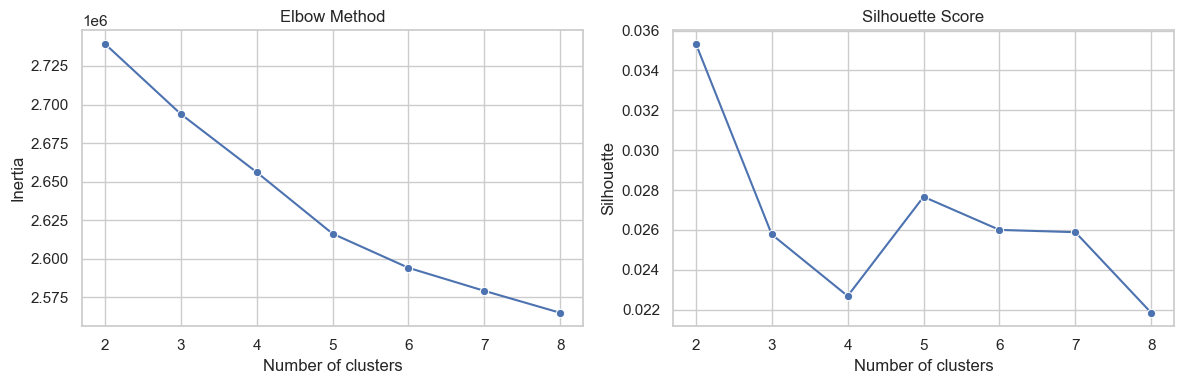

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=diagnostics_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=diagnostics_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()

In [9]:
best_k = int(diagnostics_df.loc[diagnostics_df["silhouette"].idxmax(), "k"])
print("Selected number of shopper segments:", best_k)

Selected number of shopper segments: 2


## Fit KMeans and Assign Shopper Segments

In [10]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_kmeans_sample)

train_cluster_labels = kmeans.predict(np.asarray(X_train_cluster, dtype=np.float32))

segment_counts = (
    pd.Series(train_cluster_labels, name="segment")
    .value_counts()
    .sort_index()
    .rename_axis("segment")
    .reset_index(name="user_count")
)
segment_counts["percent_of_users"] = (segment_counts["user_count"] / segment_counts["user_count"].sum() * 100).round(2)
segment_counts

,segment,user_count,percent_of_users
0,0,399601,49.95
1,1,400399,50.05


## Descriptive Segment Profiles
The matrix was already scaled and encoded during preprocessing, so positive values mean a segment is above the overall processed-feature average and negative values mean below average. The table lists the strongest feature differences that make each user group distinct.

In [11]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)

segment_profiles = []
for segment_id, row in cluster_centers.iterrows():
    strongest_positive = row.nlargest(5)
    strongest_negative = row.nsmallest(5)
    segment_profiles.append({
        "segment": segment_id,
        "users": int(segment_counts.loc[segment_counts["segment"] == segment_id, "user_count"].iloc[0]),
        "percent_of_users": float(segment_counts.loc[segment_counts["segment"] == segment_id, "percent_of_users"].iloc[0]),
        "above_average_features": ", ".join([f"{name} ({value:.2f})" for name, value in strongest_positive.items()]),
        "below_average_features": ", ".join([f"{name} ({value:.2f})" for name, value in strongest_negative.items()]),
    })

segment_profile_df = pd.DataFrame(segment_profiles)
segment_profile_df

,segment,users,percent_of_users,above_average_features,below_average_features
0,0,399601,49.95,"num__health_conscious_shopping (1.00), categor...","num__checkout_abandonments_per_month (-0.01), ..."
1,1,400399,50.05,"categorical__urban_rural_0 (0.80), categorical...","num__health_conscious_shopping (-1.00), num__m..."


In [12]:
target_mix_by_segment = pd.crosstab(
    pd.Series(train_cluster_labels, name="segment"),
    pd.Series(y_train_segments, name="spend_class"),
    normalize="index",
).mul(100).round(2)

target_mix_by_segment

spend_class,0,1,2
segment,,,
0,38.22,33.88,27.90
1,38.09,33.96,27.95


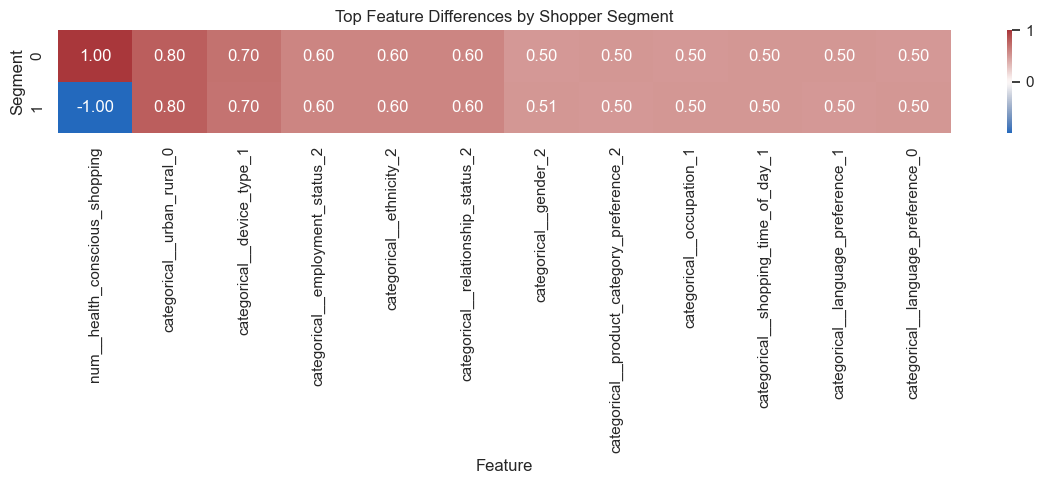

In [13]:
top_profile_features = (
    cluster_centers.abs()
    .max(axis=0)
    .sort_values(ascending=False)
    .head(12)
    .index
)

profile_heatmap = cluster_centers[top_profile_features]
plt.figure(figsize=(12, 5))
sns.heatmap(profile_heatmap, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Top Feature Differences by Shopper Segment")
plt.xlabel("Feature")
plt.ylabel("Segment")
plt.tight_layout()

## 2D Segment Visualization
PCA projects the high-dimensional shopper features into two dimensions for a quick visual check of cluster separation. This is descriptive only; KMeans is still fit on the full transformed feature space.

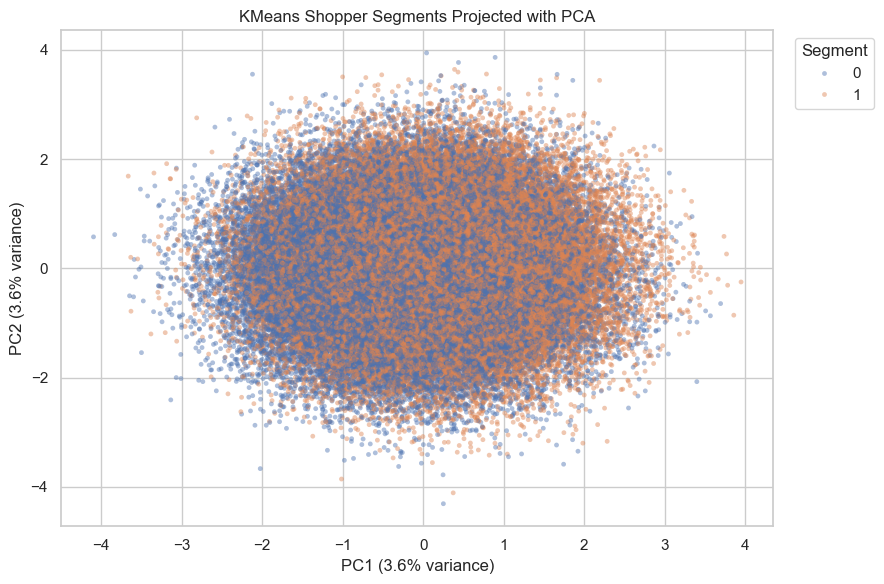

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_kmeans_sample_2d = pca.fit_transform(X_kmeans_sample)
sample_cluster_labels = kmeans.predict(X_kmeans_sample)

plot_df = pd.DataFrame({
    "pc1": X_kmeans_sample_2d[:, 0],
    "pc2": X_kmeans_sample_2d[:, 1],
    "segment": sample_cluster_labels.astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="segment", s=12, alpha=0.45, linewidth=0)
plt.title("KMeans Shopper Segments Projected with PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()